FICO Score Quantization — Optimal Bucket Boundaries
=====================================================

GOAL:
    Map continuous FICO scores (300–850) into a fixed number of
    discrete rating buckets, where bucket 1 = best credit (high FICO)
    and bucket N = worst credit (low FICO).

TWO METHODS:

    1. MSE Minimization  — treat as an approximation problem;
                           minimise squared error when replacing
                           every score in a bucket with the bucket mean.

    2. Log-Likelihood Maximization — credit-risk aware objective;
                           maximises the likelihood of observing the
                           actual default pattern given the bucketing.
                           Solved with dynamic programming (O(n²k)).

DYNAMIC PROGRAMMING INTUITION:

    Let LL[i][j] = best log-likelihood achievable using j buckets
    over the first i distinct FICO values.
    Recurrence:
        LL[i][j] = max over all split points m < i of:
                   LL[m][j-1]  +  segment_ll(m+1 … i)
    where segment_ll for a segment with n records and k defaults is:
        k·log(k/n) + (n-k)·log(1 - k/n)   if 0 < k < n
        0                                   if k=0 or k=n
    Base case: LL[i][1] = segment_ll(0 … i)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ══════════════════════════════════════════════════════════════════
# CONSTANTS
# ══════════════════════════════════════════════════════════════════

DATA_PATH    = 'cx_loan_data.csv'
N_BUCKETS    = 5          # default number of rating buckets
FICO_MIN     = 300
FICO_MAX     = 850

In [3]:
# ══════════════════════════════════════════════════════════════════
# LOAD & EXPLORE DATA
# ══════════════════════════════════════════════════════════════════

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Normalise column names — handle any capitalisation
    df.columns = [c.strip().lower() for c in df.columns]
    print("Columns found:", list(df.columns))
    return df


def explore_data(df: pd.DataFrame, fico_col: str, default_col: str):
    print("=" * 62)
    print("  DATA OVERVIEW")
    print("=" * 62)
    print(f"  Rows            : {len(df):,}")
    print(f"  FICO range      : {df[fico_col].min():.0f} – {df[fico_col].max():.0f}")
    print(f"  Default rate    : {df[default_col].mean()*100:.2f}%")
    print(f"  FICO mean ± std : {df[fico_col].mean():.1f} ± {df[fico_col].std():.1f}")
    print()

In [4]:
# ══════════════════════════════════════════════════════════════════
# METHOD A — MSE MINIMISATION (Lloyd / k-means 1-D)
# ══════════════════════════════════════════════════════════════════

def mse_optimal_boundaries(fico_scores: np.ndarray, n_buckets: int) -> list:
    """
    Find bucket boundaries that minimise the total MSE when every
    score in a bucket is replaced by the bucket mean.

    Algorithm: 1-D k-means (Lloyd's algorithm).
        1. Initialise centroids at quantile positions.
        2. Assign each score to its nearest centroid.
        3. Recompute centroids as bucket means.
        4. Repeat until convergence.
        5. Boundaries = midpoints between adjacent centroids.

    This is optimal for 1-D data (guaranteed to converge to the
    global optimum given sorted initialisation).

    Returns: sorted list of interior boundary values (length = n_buckets-1)
    """
    scores = np.sort(fico_scores)

    # Initialise centroids at evenly spaced quantiles
    quantiles  = np.linspace(0, 100, n_buckets + 2)[1:-1]
    centroids  = np.percentile(scores, quantiles)

    for _ in range(1000):
        # Assign each score to nearest centroid
        dists      = np.abs(scores[:, None] - centroids[None, :])
        labels     = np.argmin(dists, axis=1)

        new_centroids = np.array([
            scores[labels == k].mean() if (labels == k).sum() > 0 else centroids[k]
            for k in range(n_buckets)
        ])

        if np.allclose(centroids, new_centroids, atol=1e-6):
            break
        centroids = new_centroids

    centroids = np.sort(centroids)
    boundaries = [(centroids[i] + centroids[i+1]) / 2
                  for i in range(len(centroids) - 1)]
    return sorted(boundaries)


In [5]:
# ══════════════════════════════════════════════════════════════════
# STEP 3: METHOD B — LOG-LIKELIHOOD MAXIMISATION (Dynamic Programming)
# ══════════════════════════════════════════════════════════════════

def segment_log_likelihood(n: int, k: int) -> float:
    """
    Log-likelihood contribution of one bucket containing n records
    and k defaults.

        LL = k·ln(k/n) + (n-k)·ln(1 - k/n)

    Special cases:
        k = 0 → no defaults in segment → ln(1)^(n-0) = 0
        k = n → all default            → ln(1)^k      = 0
    Both cases contribute 0 (perfectly homogeneous bucket).
    """
    if n == 0 or k == 0 or k == n:
        return 0.0
    p = k / n
    return k * np.log(p) + (n - k) * np.log(1 - p)


def ll_optimal_boundaries(
    fico_scores:   np.ndarray,
    default_flags: np.ndarray,
    n_buckets:     int,
) -> list:
    """
    Find bucket boundaries that maximise the total log-likelihood
    of the observed default pattern given the bucketing.

    Solved by dynamic programming over the sorted unique FICO values.

    State: dp[i][j] = max log-likelihood using j buckets over
                      the first i FICO score positions.

    Recurrence:
        dp[i][j] = max_{j-1 <= m < i}  dp[m][j-1] + seg_ll(m, i)

    where seg_ll(m, i) is the LL of the segment from position m to i.

    Time complexity: O(F² · K) where F = unique FICO values, K = buckets.
    Space: O(F · K) for the DP table + O(F · K) for traceback.

    Returns: sorted list of interior boundary values (length = n_buckets-1)
    """
    # ── Build cumulative statistics over sorted unique FICO values ─
    df_tmp = pd.DataFrame({'fico': fico_scores, 'default': default_flags})
    grouped = (df_tmp.groupby('fico')['default']
                     .agg(['sum', 'count'])
                     .sort_index()
                     .reset_index())
    grouped.columns = ['fico', 'defaults', 'total']

    fico_vals  = grouped['fico'].values        # unique FICO scores
    F          = len(fico_vals)                # number of unique values

    # Prefix sums for O(1) segment queries
    cum_total    = np.zeros(F + 1, dtype=float)
    cum_defaults = np.zeros(F + 1, dtype=float)
    for i in range(F):
        cum_total[i+1]    = cum_total[i]    + grouped['total'].iloc[i]
        cum_defaults[i+1] = cum_defaults[i] + grouped['defaults'].iloc[i]

    def seg_ll(start: int, end: int) -> float:
        """Log-likelihood of segment covering fico_vals[start:end]."""
        n = int(cum_total[end]    - cum_total[start])
        k = int(cum_defaults[end] - cum_defaults[start])
        return segment_log_likelihood(n, k)

    # ── DP table initialisation ────────────────────────────────────
    NEG_INF = -np.inf
    # dp[i][j]  = best LL using j buckets over positions 0..i-1
    # split[i][j] = the split point that achieved dp[i][j]
    dp    = np.full((F + 1, n_buckets + 1), NEG_INF)
    split = np.zeros((F + 1, n_buckets + 1), dtype=int)

    dp[0][0] = 0.0   # base: 0 buckets over empty prefix → LL = 0

    # ── Fill DP table ──────────────────────────────────────────────
    for j in range(1, n_buckets + 1):
        for i in range(j, F + 1):           # need at least j points for j buckets
            best_val   = NEG_INF
            best_split = j - 1
            for m in range(j - 1, i):       # last bucket covers [m, i)
                if dp[m][j-1] == NEG_INF:
                    continue
                val = dp[m][j-1] + seg_ll(m, i)
                if val > best_val:
                    best_val   = val
                    best_split = m
            dp[i][j]    = best_val
            split[i][j] = best_split

    # ── Traceback to find boundary positions ──────────────────────
    boundaries_idx = []
    i = F
    for j in range(n_buckets, 0, -1):
        m = split[i][j]
        if j > 1:
            boundaries_idx.append(m)
        i = m

    boundaries_idx = sorted(boundaries_idx)

    # Convert position indices to FICO score boundaries
    # Boundary between bucket ending at position m-1 and starting at m
    # is set to the midpoint of the two adjacent unique FICO scores
    boundaries = []
    for idx in boundaries_idx:
        if 0 < idx < F:
            b = (fico_vals[idx - 1] + fico_vals[idx]) / 2.0
            boundaries.append(b)

    return sorted(boundaries)


In [6]:
# ══════════════════════════════════════════════════════════════════
#  BUILD RATING MAP
# ══════════════════════════════════════════════════════════════════

def build_rating_map(boundaries: list, method_name: str, n_buckets: int) -> dict:
    """
    Given interior boundaries, construct the full rating map.

    Rating convention (as per task):
        Rating 1 = BEST  credit (highest FICO scores)
        Rating N = WORST credit (lowest FICO scores)

    The boundaries split [FICO_MIN, FICO_MAX] into n_buckets intervals.
    We reverse-assign ratings so that the top interval = rating 1.

    Returns dict: {'boundaries': [...], 'intervals': [...], 'rating_map': {...}}
    """
    all_bounds = [FICO_MIN] + sorted(boundaries) + [FICO_MAX]
    intervals  = []
    for i in range(len(all_bounds) - 1):
        intervals.append((all_bounds[i], all_bounds[i+1]))

    # Reverse: highest FICO = rating 1
    intervals_sorted = sorted(intervals, key=lambda x: x[0], reverse=True)
    rating_map = {}
    for rating, (lo, hi) in enumerate(intervals_sorted, start=1):
        rating_map[rating] = (lo, hi)

    return {
        'method':     method_name,
        'boundaries': sorted(boundaries),
        'all_bounds': all_bounds,
        'intervals':  intervals,
        'rating_map': rating_map,
    }


def assign_rating(fico_score: float, rating_map: dict) -> int:
    """Assign a rating (1=best … N=worst) given a FICO score."""
    for rating, (lo, hi) in rating_map.items():
        if lo <= fico_score <= hi:
            return rating
    # Edge cases: clamp to nearest
    return 1 if fico_score >= FICO_MAX else len(rating_map)


In [8]:
# ══════════════════════════════════════════════════════════════════
# EVALUATE BUCKET QUALITY
# ══════════════════════════════════════════════════════════════════

def evaluate_buckets(
    fico_scores:   np.ndarray,
    default_flags: np.ndarray,
    rating_map_info: dict,
) -> pd.DataFrame:
    """
    For each bucket report:
        - FICO range
        - Count of loans
        - Number of defaults
        - Default rate (PD estimate for that bucket)
        - Rating label
        - MSE contribution
        - LL contribution
    """
    rows = []
    rm   = rating_map_info['rating_map']

    all_bounds = sorted(rating_map_info['all_bounds'])

    for i in range(len(all_bounds) - 1):
        lo, hi  = all_bounds[i], all_bounds[i+1]
        mask    = (fico_scores >= lo) & (fico_scores <= hi)
        n       = mask.sum()
        k       = int(default_flags[mask].sum())
        pd_est  = k / n if n > 0 else 0.0
        mean_f  = fico_scores[mask].mean() if n > 0 else (lo + hi) / 2
        mse_c   = float(np.sum((fico_scores[mask] - mean_f)**2)) if n > 0 else 0.0
        ll_c    = segment_log_likelihood(n, k)

        # Find rating for this interval
        mid_fico = (lo + hi) / 2
        rating   = assign_rating(mid_fico, rm)

        rows.append({
            'Rating':        rating,
            'FICO Low':      round(lo, 1),
            'FICO High':     round(hi, 1),
            'Count':         n,
            'Defaults':      k,
            'Default Rate':  f"{pd_est*100:.2f}%",
            'PD':            round(pd_est, 4),
            'MSE contrib':   round(mse_c, 1),
            'LL contrib':    round(ll_c, 3),
        })

    df_out = pd.DataFrame(rows).sort_values('Rating')
    total_mse = df_out['MSE contrib'].sum()
    total_ll  = df_out['LL contrib'].sum()
    return df_out, total_mse, total_ll


In [9]:
# ══════════════════════════════════════════════════════════════════
# VISUALISATION
# ══════════════════════════════════════════════════════════════════

def plot_results(df, fico_col, default_col, mse_info, ll_info, n_buckets):
    fico   = df[fico_col].values
    deflt  = df[default_col].values

    mse_bounds = mse_info['all_bounds']
    ll_bounds  = ll_info['all_bounds']

    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)
    fig.suptitle(f'FICO Score Quantization — {n_buckets} Buckets',
                 fontsize=15, fontweight='bold')

    # ── Panel 1: FICO distribution + MSE boundaries ───────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(fico, bins=60, color='steelblue', edgecolor='white',
             alpha=0.8, label='All loans')
    ax1.hist(fico[deflt == 1], bins=60, color='crimson', edgecolor='white',
             alpha=0.6, label='Defaults')
    for b in mse_bounds[1:-1]:
        ax1.axvline(b, color='darkorange', lw=2, linestyle='--')
    ax1.set_title('MSE Optimal Boundaries', fontweight='bold')
    ax1.set_xlabel('FICO Score')
    ax1.set_ylabel('Count')
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)

    # ── Panel 2: FICO distribution + LL boundaries ────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.hist(fico, bins=60, color='steelblue', edgecolor='white',
             alpha=0.8, label='All loans')
    ax2.hist(fico[deflt == 1], bins=60, color='crimson', edgecolor='white',
             alpha=0.6, label='Defaults')
    for b in ll_bounds[1:-1]:
        ax2.axvline(b, color='green', lw=2, linestyle='--')
    ax2.set_title('Log-Likelihood Optimal Boundaries', fontweight='bold')
    ax2.set_xlabel('FICO Score')
    ax2.set_ylabel('Count')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)

    # ── Panel 3 & 4: Default rate per bucket ─────────────────────
    for ax, info, colour, title in [
        (fig.add_subplot(gs[1, 0]), mse_info, 'darkorange', 'MSE Buckets — Default Rate'),
        (fig.add_subplot(gs[1, 1]), ll_info,  'green',      'LL Buckets  — Default Rate'),
    ]:
        bounds = info['all_bounds']
        labels, rates, counts = [], [], []
        for i in range(len(bounds) - 1):
            lo, hi = bounds[i], bounds[i+1]
            mask   = (fico >= lo) & (fico <= hi)
            n      = mask.sum()
            k      = deflt[mask].sum()
            labels.append(f"{lo:.0f}–{hi:.0f}")
            rates.append(k / n * 100 if n > 0 else 0)
            counts.append(n)
        bars = ax.bar(range(len(labels)), rates, color=colour,
                      edgecolor='black', alpha=0.8)
        for bar, cnt in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    f'n={cnt:,}', ha='center', va='bottom', fontsize=7)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=30, fontsize=8)
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('Default Rate (%)')
        ax.grid(alpha=0.3, axis='y')

    # ── Panel 5: Boundary comparison bar chart ───────────────────
    ax5 = fig.add_subplot(gs[2, 0])
    mse_b = sorted(mse_info['boundaries'])
    ll_b  = sorted(ll_info['boundaries'])
    x     = np.arange(len(mse_b))
    width = 0.35
    ax5.bar(x - width/2, mse_b, width, label='MSE boundaries',
            color='darkorange', edgecolor='black', alpha=0.85)
    ax5.bar(x + width/2, ll_b,  width, label='LL boundaries',
            color='green',      edgecolor='black', alpha=0.85)
    ax5.set_xticks(x)
    ax5.set_xticklabels([f'B{i+1}' for i in range(len(mse_b))])
    ax5.set_title('Boundary Comparison: MSE vs Log-Likelihood', fontweight='bold')
    ax5.set_ylabel('FICO Score')
    ax5.legend()
    ax5.grid(alpha=0.3, axis='y')

    # ── Panel 6: Running default rate curve + boundaries ─────────
    ax6 = fig.add_subplot(gs[2, 1])
    fico_sorted  = np.sort(np.unique(fico))
    running_pd   = []
    for f in fico_sorted:
        mask = fico >= f
        running_pd.append(deflt[mask].mean() * 100)
    ax6.plot(fico_sorted, running_pd, color='navy', lw=1.5,
             label='Default rate (FICO ≥ x)')
    for b in mse_bounds[1:-1]:
        ax6.axvline(b, color='darkorange', lw=1.5, ls='--', alpha=0.8)
    for b in ll_bounds[1:-1]:
        ax6.axvline(b, color='green', lw=1.5, ls=':', alpha=0.8)
    from matplotlib.lines import Line2D
    ax6.legend(handles=[
        Line2D([0],[0],color='navy',   lw=2, label='Default rate curve'),
        Line2D([0],[0],color='darkorange',lw=2,ls='--',label='MSE boundaries'),
        Line2D([0],[0],color='green',  lw=2, ls=':',  label='LL boundaries'),
    ], fontsize=8)
    ax6.set_title('Default Rate Curve & Boundaries', fontweight='bold')
    ax6.set_xlabel('FICO Score')
    ax6.set_ylabel('Default Rate (FICO ≥ x) %')
    ax6.grid(alpha=0.3)

    plt.savefig('fico_quantization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("[✓] Chart saved → fico_quantization.png")

In [11]:
# ══════════════════════════════════════════════════════════════════
# THE CORE FUNCTION — build_fico_rating_map()
# ══════════════════════════════════════════════════════════════════

def build_fico_rating_map(
    fico_scores:   np.ndarray,
    default_flags: np.ndarray,
    n_buckets:     int   = 5,
    method:        str   = 'll',       # 'mse' or 'll' or 'both'
) -> dict:
    """
    Primary API: given FICO scores + default labels, return the
    optimal rating map using the specified method.

    Parameters
    ----------
    fico_scores   : array of FICO scores (300–850)
    default_flags : array of 0/1 default indicators (same length)
    n_buckets     : number of rating buckets to create
    method        : 'mse'  → minimise MSE (k-means 1D)
                    'll'   → maximise log-likelihood (dynamic programming)
                    'both' → run both and return dict of both

    Returns
    -------
    If method in ('mse', 'll'):
        dict with keys: 'boundaries', 'rating_map', 'method'
    If method == 'both':
        dict with keys: 'mse' → (above dict), 'll' → (above dict)
    """
    if method in ('mse', 'both'):
        mse_bounds = mse_optimal_boundaries(fico_scores, n_buckets)
        mse_map    = build_rating_map(mse_bounds, 'MSE', n_buckets)

    if method in ('ll', 'both'):
        ll_bounds  = ll_optimal_boundaries(fico_scores, default_flags, n_buckets)
        ll_map     = build_rating_map(ll_bounds, 'Log-Likelihood', n_buckets)

    if method == 'mse':  return mse_map
    if method == 'll':   return ll_map
    return {'mse': mse_map, 'll': ll_map}


def get_rating(fico_score: float, rating_map_info: dict) -> int:
    """
    Score a single borrower.
    Returns integer rating: 1 = best, N = worst.
    """
    return assign_rating(fico_score, rating_map_info['rating_map'])


def get_pd_from_rating(
    fico_score:    float,
    rating_map_info: dict,
    fico_scores:   np.ndarray,
    default_flags: np.ndarray,
) -> float:
    """
    Return the historical PD of the bucket this borrower falls into.
    This PD is the best estimate for the borrower's default probability.
    """
    rm = rating_map_info['rating_map']
    rating = assign_rating(fico_score, rm)
    lo, hi = rm[rating]
    mask   = (fico_scores >= lo) & (fico_scores <= hi)
    n = mask.sum()
    if n == 0:
        return 0.0
    return float(default_flags[mask].mean())


Columns found: ['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'default']
  Using: FICO='fico_score',  Default='default'

  DATA OVERVIEW
  Rows            : 10,000
  FICO range      : 408 – 850
  Default rate    : 18.51%
  FICO mean ± std : 637.6 ± 60.7

  Computing MSE-optimal boundaries (k-means 1-D)...
  Computing Log-Likelihood-optimal boundaries (DP)...

  METHOD A: MSE-OPTIMAL BOUNDARIES
  Boundaries : [np.float64(559.3), np.float64(613.0), np.float64(658.6), np.float64(708.8)]
  Total MSE  : 2,987,631.5

 Rating  FICO Low  FICO High  Count  Defaults Default Rate     PD  MSE contrib  LL contrib
      1     708.8      850.0   1214        53        4.37% 0.0437     759309.9    -217.789
      2     658.6      708.8   2461       217        8.82% 0.0882     483189.6    -734.107
      3     613.0      658.6   2921       441       15.10% 0.1510     481796.9   -1239.666
      4     559.3      613.0  

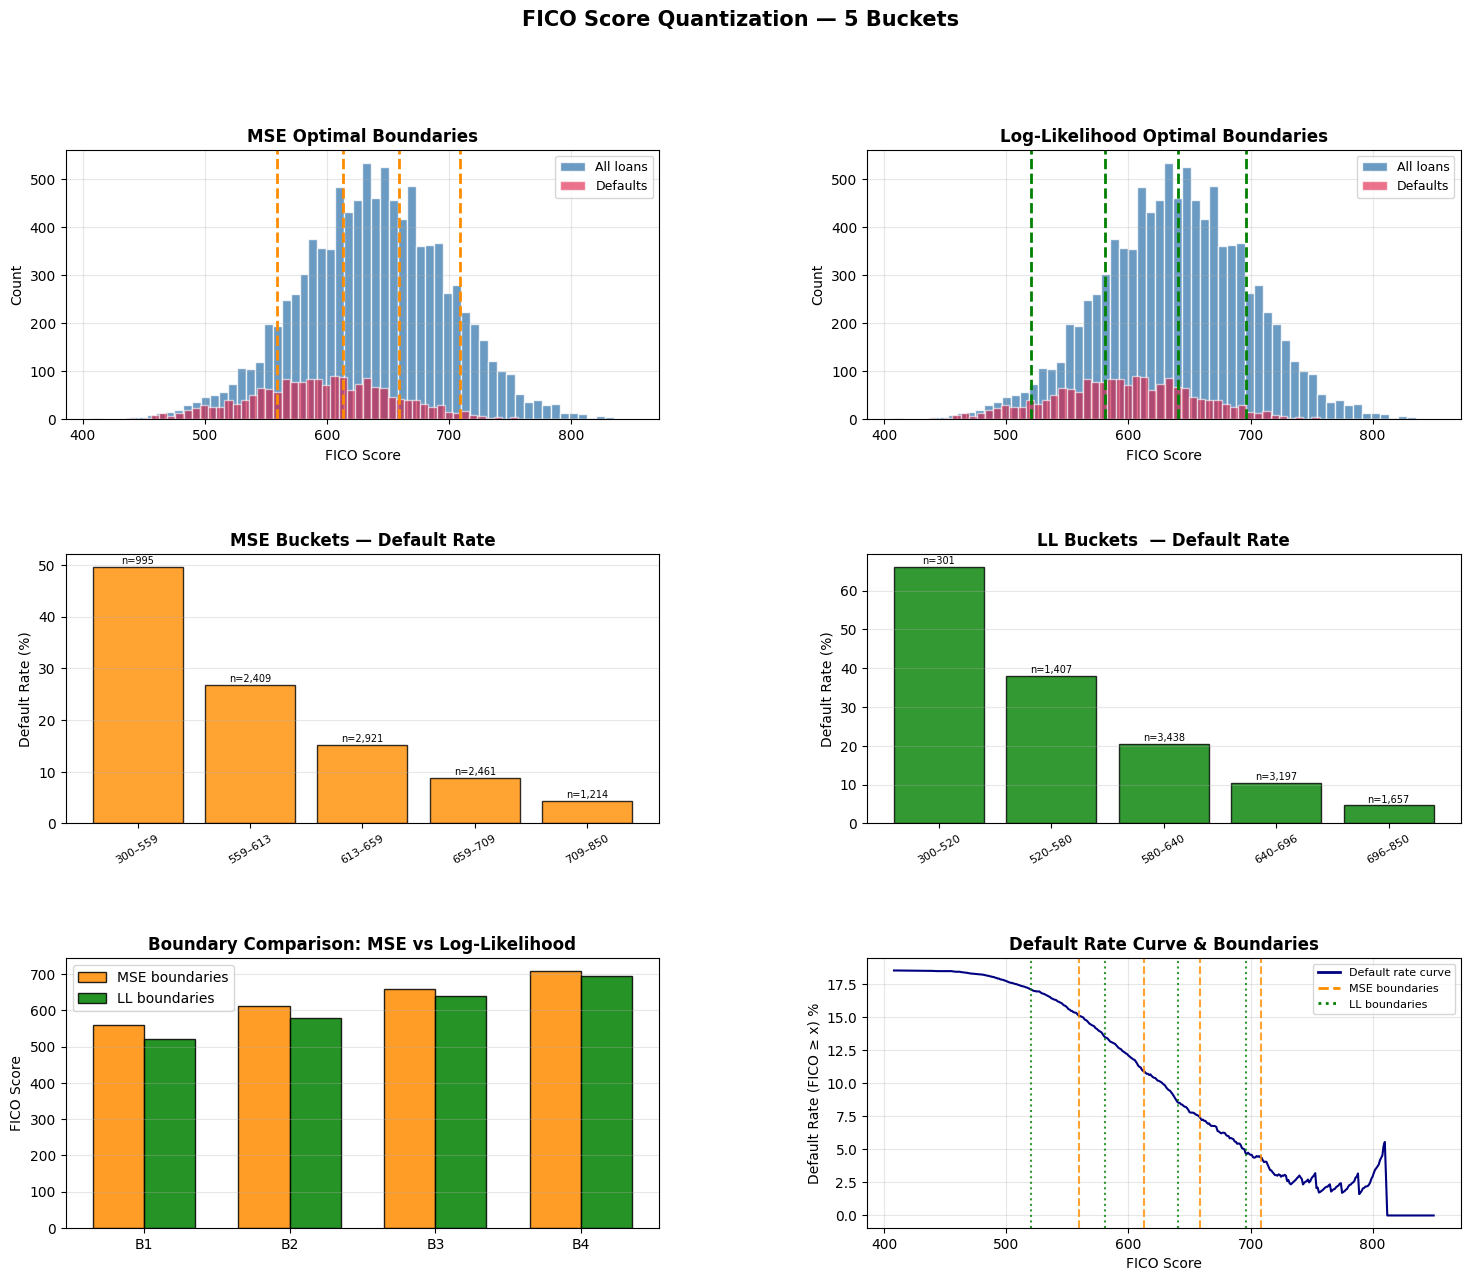

[✓] Chart saved → fico_quantization.png

  DEMO — SCORING NEW BORROWERS

  Using Log-Likelihood map (5 buckets):
    FICO    Rating        Bucket Range   Historical PD
  ──────  ────────  ──────────────────  ──────────────
     800         1  696 – 850                  4.65%
     740         1  696 – 850                  4.65%
     680         2  640 – 696                 10.51%
     620         3  580 – 640                 20.45%
     560         4  520 – 580                 38.10%
     490         5  300 – 520                 66.11%

  SENSITIVITY — LL BOUNDARIES FOR DIFFERENT N_BUCKETS
     N  Boundaries
  ────  ──────────────────────────────────────────────────
     3  [np.float64(579.5), np.float64(649.5)]
     4  [np.float64(552.5), np.float64(610.5), np.float64(649.5)]
     5  [np.float64(520.5), np.float64(580.5), np.float64(640.5), np.float64(696.5)]
     6  [np.float64(520.5), np.float64(579.5), np.float64(611.5), np.float64(649.5), np.float64(719.5)]
     7  [np.float64(520.

In [13]:
# ══════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════

if __name__ == '__main__':

    # 1. Load
    df = load_data(DATA_PATH)

    # Auto-detect column names
    fico_col    = next(c for c in df.columns if 'fico' in c.lower())
    default_col = next(c for c in df.columns if 'default' in c.lower())
    print(f"  Using: FICO='{fico_col}',  Default='{default_col}'\n")

    explore_data(df, fico_col, default_col)

    fico   = df[fico_col].values.astype(float)
    deflt  = df[default_col].values.astype(int)

    # 2. Run both methods
    print("  Computing MSE-optimal boundaries (k-means 1-D)...")
    mse_bounds = mse_optimal_boundaries(fico, N_BUCKETS)
    mse_info   = build_rating_map(mse_bounds, 'MSE', N_BUCKETS)
    mse_table, mse_total, _  = evaluate_buckets(fico, deflt, mse_info)

    print("  Computing Log-Likelihood-optimal boundaries (DP)...")
    ll_bounds  = ll_optimal_boundaries(fico, deflt, N_BUCKETS)
    ll_info    = build_rating_map(ll_bounds, 'Log-Likelihood', N_BUCKETS)
    ll_table, _, ll_total    = evaluate_buckets(fico, deflt, ll_info)

    # 3. Print results
    print("\n" + "=" * 62)
    print("  METHOD A: MSE-OPTIMAL BOUNDARIES")
    print("=" * 62)
    print(f"  Boundaries : {[round(b,1) for b in mse_bounds]}")
    print(f"  Total MSE  : {mse_total:,.1f}\n")
    print(mse_table.to_string(index=False))

    print("\n" + "=" * 62)
    print("  METHOD B: LOG-LIKELIHOOD-OPTIMAL BOUNDARIES (DP)")
    print("=" * 62)
    print(f"  Boundaries : {[round(b,1) for b in ll_bounds]}")
    print(f"  Total LL   : {ll_total:.4f}\n")
    print(ll_table.to_string(index=False))

    # 4. Visualise
    plot_results(df, fico_col, default_col, mse_info, ll_info, N_BUCKETS)

    # 5. Demo: using the rating map on new borrowers
    print("\n" + "=" * 62)
    print("  DEMO — SCORING NEW BORROWERS")
    print("=" * 62)
    test_ficos = [800, 740, 680, 620, 560, 490]
    rm_ll = ll_info['rating_map']
    print(f"\n  Using Log-Likelihood map ({N_BUCKETS} buckets):")
    print(f"  {'FICO':>6}  {'Rating':>8}  {'Bucket Range':>18}  {'Historical PD':>14}")
    print(f"  {'─'*6}  {'─'*8}  {'─'*18}  {'─'*14}")
    for f in test_ficos:
        rating  = assign_rating(f, rm_ll)
        lo, hi  = rm_ll[rating]
        pd_est  = get_pd_from_rating(f, ll_info, fico, deflt)
        print(f"  {f:>6}  {rating:>8}  {lo:.0f} – {hi:.0f}{'':>8}  {pd_est*100:>12.2f}%")

    # 6. Sensitivity: how do boundaries change with N_BUCKETS?
    print("\n" + "=" * 62)
    print("  SENSITIVITY — LL BOUNDARIES FOR DIFFERENT N_BUCKETS")
    print("=" * 62)
    print(f"  {'N':>4}  {'Boundaries'}")
    print(f"  {'─'*4}  {'─'*50}")
    for n in [3, 4, 5, 6, 7, 8]:
        b = ll_optimal_boundaries(fico, deflt, n)
        print(f"  {n:>4}  {[round(x,1) for x in b]}")

    # 7. Build and return the final map (for downstream use)
    print("\n" + "=" * 62)
    print("  FINAL RATING MAP (Log-Likelihood, 5 buckets)")
    print("=" * 62)
    final_map = build_fico_rating_map(fico, deflt, n_buckets=5, method='ll')
    print(f"\n  {'Rating':>8}  {'FICO Range':>20}  {'Interpretation'}")
    print(f"  {'─'*8}  {'─'*20}  {'─'*25}")
    interp = {1:'Prime / Excellent',2:'Near-Prime / Good',
              3:'Average / Fair',4:'Below Average',5:'Subprime / Poor'}
    for rating, (lo, hi) in final_map['rating_map'].items():
        print(f"  {rating:>8}  {lo:.0f} – {hi:.0f}{'':>10}  {interp.get(rating,'')}")